**Task 1.1**

In [ ]:
#Importing the libraries
import pandas as pd
import numpy as np


In [ ]:
#reading and storring the data
df = pd.read_csv("/content/train.csv")

In [ ]:
#printing the first few rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
#Printing the shape of the dataset
print(df.shape)

(891, 12)


In [ ]:
#Checking for missing vals

#Replacing the undetected nulls with the ones that pandas knows
notdetect = ["N\\A","NA","not reported", "unknown", "?"] # the unknown nulls to pandas
df = df.replace(notdetect, np.nan)

#Checking the number of nulls in each col
print("----------Num Of Nulls-------")
print(df.isna().sum())

#Dropping what needs to be dropped
df = df.drop(["Cabin"], axis=1) #The most of this col is null, so its better to drop it, becuase its hard to fill it.
df = df.dropna() # I removed the rest of the rows that had any nulls, becuase its hard to fill and anticipate someones age and where they embarked from.

----------Num Of Nulls-------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
#Checking class balance
df.info() # We can see that all the cols have the same num of rows, 712 rows.

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    object 
 4   Sex          712 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    object 
 9   Fare         712 non-null    float64
 10  Embarked     712 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 66.8+ KB


**Task 1.2**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Survived", "Name", "Sex", "Ticket", "Embarked"])
y = df["Survived"] # I didn't understand how to do this code, so i copiedd the instrucion and gave it to gemini to help me understand, then i wrote the code.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
) #This code and the import, i took it from the given file.

**Task 1.3**

In [ ]:
#Imports
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt


In [ ]:
#Training the models and reporting important metrics
random_state = 42
models = {
    "LogisticRegression": LogisticRegression(max_iter=200),
    "KNN":  KNeighborsClassifier(n_neighbors=5,),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=random_state),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    results.append((name, acc, prec, rec, f1))

results_df = pd.DataFrame(results, columns=["model", "accuracy", "precision", "recall", "f1"])
print(results_df.sort_values(by="f1", ascending=False))

#I took this code from numerous colab notebooks, that are provided in the slides, but i also made some changes.
# https://colab.research.google.com/drive/1MkpN2aAzzx1BG4LpKOtwa8G6nuB9svdb?usp=drive_link#scrollTo=RE_k_sdLVjKv
# https://colab.research.google.com/drive/1iGWgVJiLxnEJc764piC_SVsfl8Abi3EP?usp=sharing#scrollTo=E8dFKjt_3uRA



                model  accuracy  precision    recall        f1
2        RandomForest  0.692308   0.625000  0.603448  0.614035
0  LogisticRegression  0.706294   0.690476  0.500000  0.580000
1                 KNN  0.573427   0.472727  0.448276  0.460177


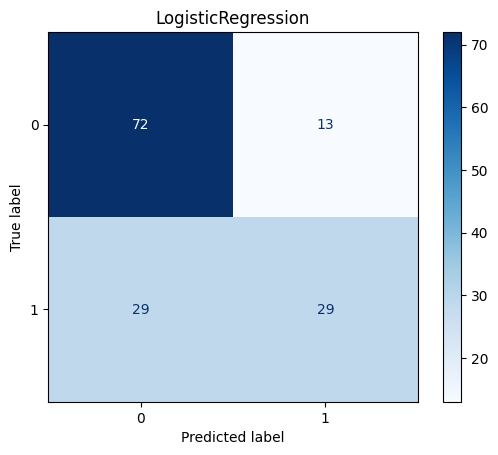

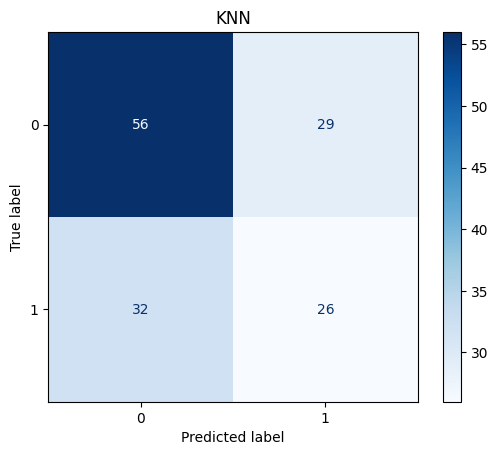

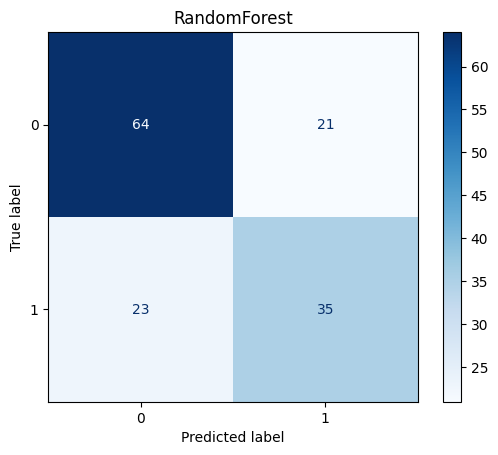

In [ ]:
#Ploting a confusion matrix for each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix = cm)
    disp.plot(cmap="Blues")
    plt.title(name)
    plt.show()


In [ ]:
#Putting the results in one summary table
result_list=[]
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    #Entering vals into the made list
    result_list.append({
        "Name": name,
        "Accuracy" : acc,
        "Precision" : prec,
        "Recall" : rec,
        "F1 Score" : f1
    })
#Turning the list into a pd dataframe
summary_df = pd.DataFrame(result_list)
#Sorting the vals by f1 score to find the best model,
summary_df = summary_df.sort_values(by= "F1 Score", ascending=False).reset_index(drop=True)
display(summary_df)
#When looking at the table, we find that the RandomForest model is the best based on the f1 score!


#I used gemini to help in understanding the instruction, and implementing the code, but I was the one who wrote the code.


,Name,Accuracy,Precision,Recall,F1 Score
0,RandomForest,0.692308,0.625000,0.603448,0.614035
1,LogisticRegression,0.706294,0.690476,0.500000,0.580000
2,KNN,0.573427,0.472727,0.448276,0.460177


**Task 2.1**

In [ ]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.utils import to_categorical


In [ ]:
input_dim = X_train.shape[1]
hidden_1 = 8
hidden_2 = 4
hidden_activation = "relu"
epochs = 10
dropout_rate = 0.3


In [ ]:
#Sigmoid plain without dropout
model_sigmoid_plain = Sequential([
    Dense(hidden_1, activation = hidden_activation, input_shape =(input_dim,)),
    Dense(hidden_2, activation = hidden_activation),
    Dense(1, activation = "sigmoid")
])

model_sigmoid_plain.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])
model_sigmoid_plain_fit = model_sigmoid_plain.fit(X_train, y_train, epochs=epochs)

#Sigmoid with dropout
model_sigmoid_wDO = Sequential([
    Dense(hidden_1, activation = hidden_activation, input_shape =(input_dim,)),
    Dropout(dropout_rate),
    Dense(hidden_2, activation = hidden_activation),
    Dropout(dropout_rate),
    Dense(1, activation = "sigmoid")
])

model_sigmoid_wDO.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])
model_sigmoid_fit = model_sigmoid_plain.fit(X_train, y_train,
                                            epochs=epochs,
                                            validation_data = (X_test, y_test))
model_sigmoid_wDo_fit = model_sigmoid_wDO.fit(X_train, y_train,
                                              epochs=epochs,
                                              validation_data = (X_test, y_test))
print("training accuracy:", round(float(model_sigmoid_fit.history["accuracy"][-1]), 3))
print("Final training with Dropout layers accuracy:", round(float(model_sigmoid_wDo_fit.history["accuracy"][-1]), 3))


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5958 - loss: 55.9200
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6063 - loss: 27.3822
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6432 - loss: 7.2070
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6292 - loss: 3.7393
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6661 - loss: 3.0455
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6661 - loss: 2.8870
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6731 - loss: 2.7643 
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6801 - loss: 2.5724 
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6801 - loss: 2.4707 
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6907 - loss: 2.2919
Epoch 1/10
 1/18 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6875 - loss: 2.7353

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6977 - loss: 2.1483 - val_accuracy: 0.6084 - val_loss: 2.8911
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6960 - loss: 2.0430 - val_accuracy: 0.5874 - val_loss: 2.7410
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6907 - loss: 1.9051 - val_accuracy: 0.5944 - val_loss: 2.5368
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6889 - loss: 1.8163 - val_accuracy: 0.5944 - val_loss: 2.3692
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6942 - loss: 1.6693 - val_accuracy: 0.6643 - val_loss: 2.1815
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6872 - loss: 1.5116 - val_accuracy: 0.6224 - val_loss: 1.8064
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6942 - loss: 1.3051 - val_accuracy: 0.6573 - val_loss: 1.5674
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6977 - loss: 1.1713 - val_accuracy: 0.6503 - val_loss: 1.4042
Ep

In [ ]:
#Softmax
y_train_encoded = to_categorical(y_train, num_classes = 2)
y_test_encoded = to_categorical(y_test, num_classes = 2)

#Softmax without dropout
model_softmax_plain = Sequential([
    Dense(hidden_1, activation = hidden_activation, input_shape = (input_dim,)),
    Dense(hidden_2, activation = hidden_activation),
    Dense(2, activation="softmax")
])

model_softmax_plain.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])


#Softmax with dropout
model_softmax_wDO = Sequential([
    Dense(hidden_1, activation = hidden_activation, input_shape = (input_dim,)),
    Dropout(dropout_rate),
    Dense(hidden_2, activation = hidden_activation),
    Dropout(dropout_rate),
    Dense(2, activation="softmax")
])

model_softmax_wDO.compile(optimizer = "adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])




model_softmax_plain.compile(optimizer= "adam", loss ="categorical_crossentropy", metrics = ["accuracy"])
model_softmax_fit = model_softmax_plain.fit(X_train,y_train_encoded,
                                            epochs = epochs,
                                            validation_data = (X_test, y_test_encoded))
model_softmax_wDo_fit = model_softmax_wDO.fit(X_train, y_train_encoded,
                                              epochs=epochs,
                                              validation_data= (X_test, y_test_encoded))

print("training accuracy:", round(float(model_softmax_fit.history["accuracy"][-1]), 3))
print("Final training with Dropout layers accuracy:", round(float(model_softmax_wDo_fit.history["accuracy"][-1]), 3))


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6028 - loss: 1.0944 - val_accuracy: 0.6573 - val_loss: 0.7708
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5958 - loss: 1.0371 - val_accuracy: 0.6364 - val_loss: 0.7772
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5975 - loss: 1.0122 - val_accuracy: 0.6573 - val_loss: 0.7494
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5958 - loss: 0.9700 - val_accuracy: 0.6224 - val_loss: 0.7621
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5975 - loss: 0.9521 - val_accuracy: 0.6294 - val_loss: 0.7525
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5940 - loss: 0.9198 - val_accuracy: 0.6364 - val_loss: 0.7426
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5958 - loss: 0.8943 - val_accuracy: 0.6084 - val_loss: 0.7492
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5958 - loss: 0.8766 - val_accuracy: 0.6084 - val_loss: 0.7394
Ep

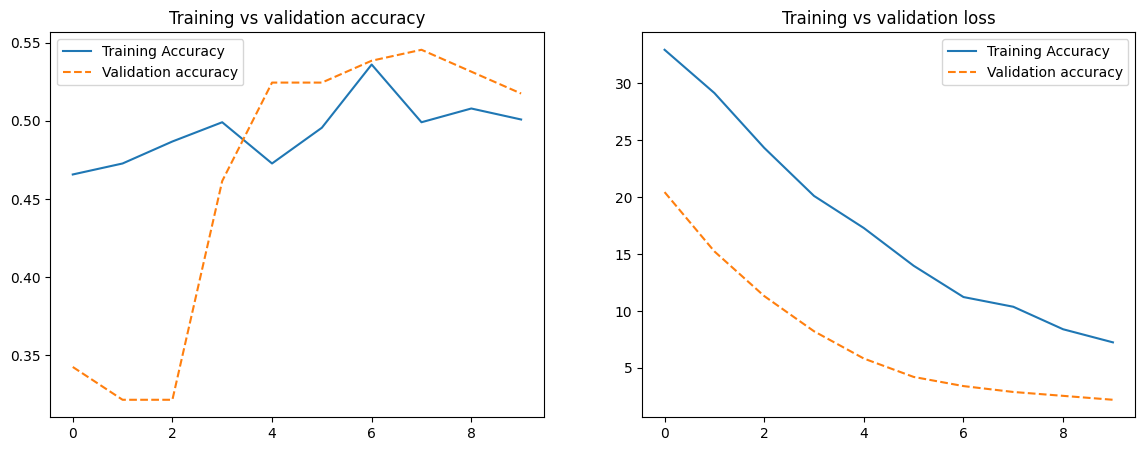

In [ ]:
#plotting for softmax with dropout


fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14, 5) )



#Accuracy
ax1.plot(model_softmax_wDo_fit.history["accuracy"], label = "Training Accuracy")
ax1.plot(model_softmax_wDo_fit.history["val_accuracy"], label = "Validation accuracy", linestyle = "--")
ax1.set_title("Training vs validation accuracy")
ax1.legend()


#loss
ax2.plot(model_softmax_wDo_fit.history["loss"], label = "Training Accuracy")
ax2.plot(model_softmax_wDo_fit.history["val_loss"], label = "Validation accuracy", linestyle = "--")
ax2.set_title("Training vs validation loss")
ax2.legend()

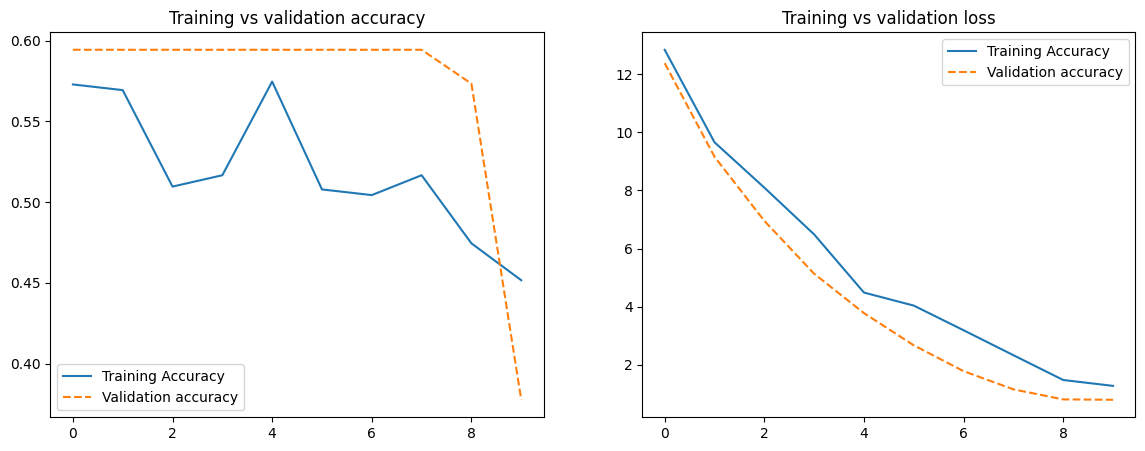

In [ ]:
#Plotting for Sigmoid with dropout

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (14, 5) )



#Accuracy
ax1.plot(model_sigmoid_wDo_fit.history["accuracy"], label = "Training Accuracy")
ax1.plot(model_sigmoid_wDo_fit.history["val_accuracy"], label = "Validation accuracy", linestyle = "--")
ax1.set_title("Training vs validation accuracy")
ax1.legend()


#loss
ax2.plot(model_sigmoid_wDo_fit.history["loss"], label = "Training Accuracy")
ax2.plot(model_sigmoid_wDo_fit.history["val_loss"], label = "Validation accuracy", linestyle = "--")
ax2.set_title("Training vs validation loss")
ax2.legend()

**Step 2.2**

In [ ]:
#Evaluating the two models and comparing them to the step 1 models

# Softmax with dopout
softmax_preds = model_softmax_wDO.predict(X_test)
softmax_preds = np.argmax(softmax_preds, axis =1)

softmax_results = {
    "Name" : "Neural Network (Softmax + Dropout)",
    "Accuracy" : accuracy_score(y_test, softmax_preds),
    "Precision" : precision_score(y_test, softmax_preds, zero_division = 0),
    "Recall" : recall_score(y_test, softmax_preds, zero_division = 0),
    "F1 Score" : f1_score(y_test, softmax_preds, zero_division = 0)
}




# Sigmoid with dropout
sigmoid_preds = model_sigmoid_wDO.predict(X_test)
sigmoid_preds = (sigmoid_preds > 0.5).astype("int32").flatten()

sigmoid_results = {
    "Name" : "Neural Network (Sigmoid + Dropout)",
    "Accuracy" : accuracy_score(y_test, sigmoid_preds),
    "Precision" : precision_score(y_test, sigmoid_preds, zero_division = 0),
    "Recall" : recall_score(y_test, sigmoid_preds, zero_division = 0),
    "F1 Score" : f1_score(y_test, sigmoid_preds, zero_division = 0)
}



#Turning the dicts into a df and then adding them to the step 1 table

comparision_df = pd.DataFrame([sigmoid_results, softmax_results])
summary_df = pd.concat([summary_df, comparision_df], ignore_index = True)
summary_df = summary_df.sort_values(by= "F1 Score", ascending=False).reset_index(drop=True)

display(summary_df)
'''
We can see that the neural networks are better than some models from step 1, but also worse than some models.
So maybe its better if we stick to the models from step 1, specially the RandomForest
'''



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


,Name,Accuracy,Precision,Recall,F1 Score
0,RandomForest,0.692308,0.625000,0.603448,0.614035
1,LogisticRegression,0.706294,0.690476,0.500000,0.580000
2,Neural Network (Sigmoid + Dropout),0.377622,0.381679,0.862069,0.529101
3,KNN,0.573427,0.472727,0.448276,0.460177
4,Neural Network (Softmax + Dropout),0.517483,0.342857,0.206897,0.258065


'\nWe can see that the neural networks are better than some models from step 1, but also worse than some models.\nSo maybe its better if we stick to the models from step 1, specially the RandomForest\n'